# 06 – Zusammenhänge erkennen und mit PCA neue Merkmale bilden
Wir verwenden die im vorigen Notebook entwickelten Merkmale aus echten Lagersignalen. **Ziel:** Korrelationen sichtbar machen, ähnliche Informationen zusammenfassen und nachvollziehen, wie ein neues Merkmal als gewichtete Kombination entsteht.

Dieses Notebook läuft auch unabhängig von Notebook 05. Beim ersten Start lädt es dieselben vier [CWRU-Aufnahmen](https://engineering.case.edu/bearingdatacenter/download-data-file). Dauer: ca. 35–45 Minuten. Eine anschauliche Einführung; die ausführlichere PCA-Behandlung folgt in Set 11.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Start aus dem Repository, Set-Ordner oder einem Übungsordner möglich.
kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set3-datenanalyse-und-visualisierung")
                   if (p / "sensor_features.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Bitte das Notebook innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from sensor_features import FS, lade_aufnahmen, spektrum, signal_merkmale, erstelle_feature_tabelle

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

signale, metadata = lade_aufnahmen()
features = erstelle_feature_tabelle(signale, metadata)
merkmal_spalten = features.columns.drop(["aufnahme", "zustand", "fenster", "start_s"]).tolist()
X = features[merkmal_spalten]
display(X.head().round(3))

,rms,mittel_abs,peak,peak_to_peak,crest_faktor,kurtosis,spektralschwerpunkt_hz,peak_frequenz_hz,band_0_1000,band_1000_3000,band_3000_6000,band_6000_24000
0,0.074,0.059,0.285,0.520,3.837,2.878,3376.184,4142.578,0.232,0.083,0.635,0.051
1,0.071,0.057,0.248,0.461,3.481,2.804,3602.330,4142.578,0.163,0.102,0.678,0.057
2,0.073,0.059,0.250,0.486,3.451,2.719,3484.412,4142.578,0.204,0.086,0.653,0.057
3,0.073,0.059,0.297,0.518,4.068,2.718,3472.698,4142.578,0.205,0.085,0.656,0.054
4,0.071,0.057,0.252,0.468,3.536,2.749,3503.108,4142.578,0.205,0.085,0.650,0.060


## 1. Welche Merkmale laufen gemeinsam?
Eine positive Korrelation bedeutet: Hohe Werte des einen Merkmals gehen hier häufig mit hohen Werten des anderen einher. Eine negative Korrelation beschreibt gegenläufige Veränderungen. Korrelation ist keine Kausalität und erfasst vor allem lineare Zusammenhänge.

Wir suchen besonders RMS/mittleren Absolutwert und Peak/Peak-to-Peak. Die Energieanteile haben außerdem eine feste Summe von 1: Ihre Abhängigkeit ist durch die Konstruktion bedingt.

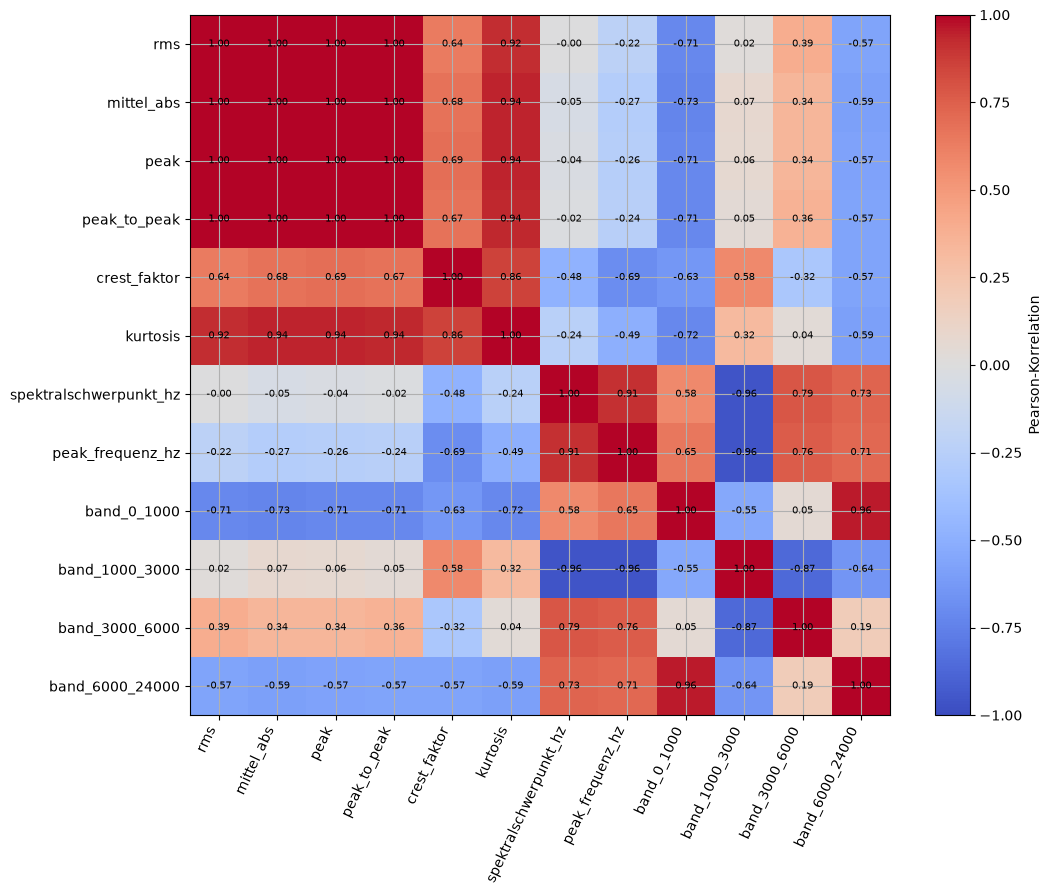

In [3]:
korrelation = X.corr()
fig, ax = plt.subplots(figsize=(11, 9))
bild = ax.imshow(korrelation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(X.columns)), X.columns, rotation=65, ha="right")
ax.set_yticks(range(len(X.columns)), X.columns)
for i in range(len(X.columns)):
    for j in range(len(X.columns)):
        ax.text(j, i, f"{korrelation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(bild, ax=ax, label="Pearson-Korrelation")
plt.tight_layout(); plt.show()

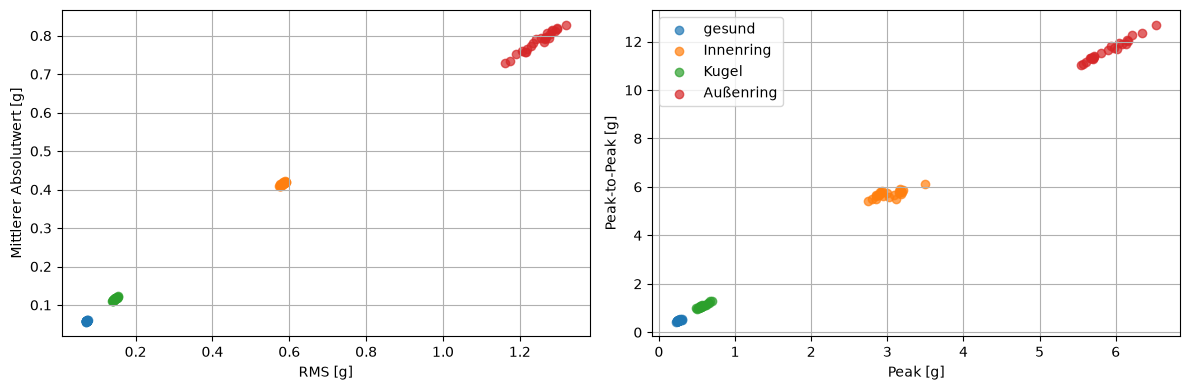

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for zustand, gruppe in features.groupby("zustand", sort=False):
    axes[0].scatter(gruppe.rms, gruppe.mittel_abs, label=zustand, alpha=0.7)
    axes[1].scatter(gruppe.peak, gruppe.peak_to_peak, label=zustand, alpha=0.7)
axes[0].set(xlabel="RMS [g]", ylabel="Mittlerer Absolutwert [g]")
axes[1].set(xlabel="Peak [g]", ylabel="Peak-to-Peak [g]")
axes[1].legend(); plt.tight_layout(); plt.show()

**Diskussion:** Ist ein Zusammenhang auch innerhalb jeder Farbe erkennbar oder entsteht er vor allem durch Unterschiede zwischen den vier Aufnahmen? Für PCA zählt beides als Varianz. Die Farben dienen nur der Interpretation.

## 2. Vor PCA die Größenordnungen vergleichbar machen
RMS wird in g gemessen, die Peak-Frequenz in Hz. Ohne Skalierung würden die großen Zahlenwerte in Hz dominieren. Standardisierung bedeutet pro Merkmal: Mittelwert abziehen und durch Standardabweichung teilen. Danach hat jedes Merkmal Mittelwert 0 und Standardabweichung 1.

Wir entfernen ein Energieband, weil seine Information bereits in den anderen drei Anteilen steckt (`letztes Band = 1 − Summe der anderen`). Die Korrelationsgrafik oben zeigt bewusst alle Merkmale.

In [5]:
pca_spalten = [c for c in merkmal_spalten if c != "band_6000_24000"]
X_pca = features[pca_spalten]
skalierer = StandardScaler()
Z = skalierer.fit_transform(X_pca)
display(pd.DataFrame({"Original-Std": X_pca.std(ddof=0),
                      "Mittelwert skaliert": Z.mean(axis=0),
                      "Std skaliert": Z.std(axis=0)}, index=pca_spalten).round(4))

,Original-Std,Mittelwert skaliert,Std skaliert
rms,0.4686,0.0,1.0
mittel_abs,0.2893,-0.0,1.0
peak,2.2734,-0.0,1.0
peak_to_peak,4.4796,-0.0,1.0
crest_faktor,0.7150,-0.0,1.0
kurtosis,1.7471,0.0,1.0
spektralschwerpunkt_hz,263.1722,0.0,1.0
peak_frequenz_hz,596.5387,-0.0,1.0
band_0_1000,0.0759,-0.0,1.0
band_1000_3000,0.1949,-0.0,1.0


## 3. PCA zuerst an zwei Merkmalen verstehen
Zwei stark korrelierte Merkmale bilden oft eine längliche Punktwolke. PCA sucht eine Richtung durch diese Wolke, in der die Streuung am größten ist (**PC1**). Die zweite Richtung steht senkrecht dazu (**PC2**) und erklärt die verbleibende Streuung.

Ein Punkt wird auf diese neuen Achsen projiziert. Bei nur einer Komponente beschreiben wir die gemeinsame Veränderung mit einer Zahl; Unterschiede quer zur Hauptachse gehen verloren. Hier lassen wir PCA die Achsen aus RMS und mittlerem Absolutwert lernen.

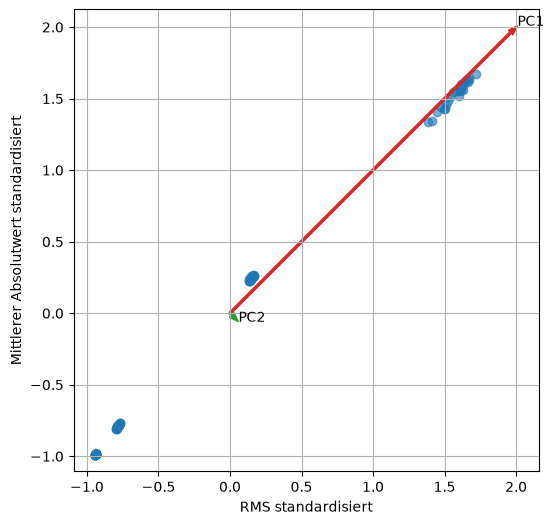

Erklärte Varianz: [0.999 0.001]


In [6]:
paar = ["rms", "mittel_abs"]
Z_paar = StandardScaler().fit_transform(features[paar])
pca_paar = PCA(n_components=2).fit(Z_paar)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Z_paar[:, 0], Z_paar[:, 1], alpha=0.6)
for i, (richtung, varianz) in enumerate(zip(pca_paar.components_, pca_paar.explained_variance_)):
    ende = richtung * 2 * np.sqrt(varianz)
    ax.arrow(0, 0, ende[0], ende[1], width=0.015, length_includes_head=True,
             color=["tab:red", "tab:green"][i])
    ax.text(ende[0], ende[1], f"PC{i + 1}")
ax.set(xlabel="RMS standardisiert", ylabel="Mittlerer Absolutwert standardisiert")
ax.set_aspect("equal", adjustable="datalim")
plt.show()
print("Erklärte Varianz:", np.round(pca_paar.explained_variance_ratio_, 3))

## 4. Jetzt alle gewählten Sensormerkmale zusammenfassen
PCA nutzt **keine Zustandslabels**. PC1 ist die gewichtete Kombination mit der größten Streuung, PC2 die nächste dazu orthogonale Kombination. Die Komponenten sind neue numerische Merkmale; sie sind keine Klassen und keine Fehlerwahrscheinlichkeiten.

Die erklärte Varianz misst, wie viel Streuung der standardisierten Merkmale erhalten bleibt. Sie garantiert weder den Erhalt aller Diagnoseinformationen noch gute Klassifikation.

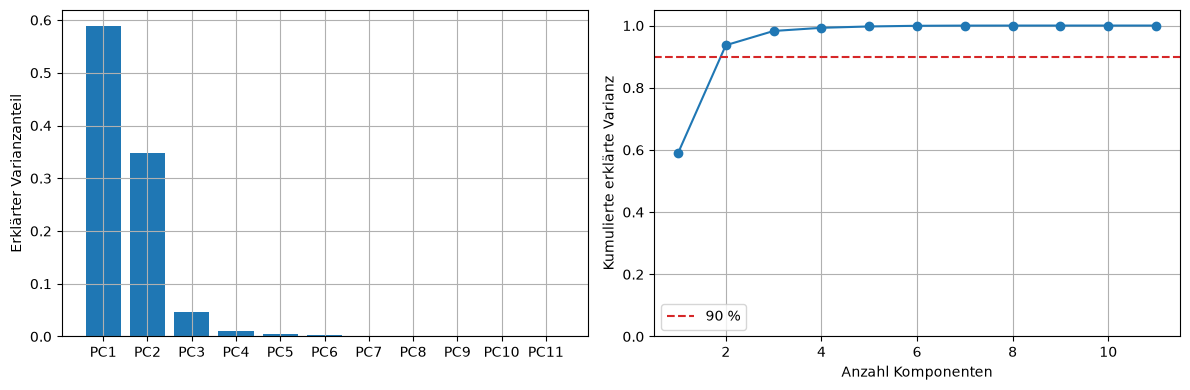

2 von 11 Komponenten erhalten mindestens 90 % der Varianz.
PC1 + PC2 erhalten 93.7% der Varianz.


In [7]:
pca = PCA().fit(Z)
scores = pca.transform(Z)
namen = [f"PC{i + 1}" for i in range(scores.shape[1])]
varianz = pca.explained_variance_ratio_
k90 = np.searchsorted(np.cumsum(varianz), 0.90) + 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(namen, varianz)
axes[0].set_ylabel("Erklärter Varianzanteil")
axes[1].plot(range(1, len(varianz) + 1), np.cumsum(varianz), marker="o")
axes[1].axhline(0.9, color="tab:red", linestyle="--", label="90 %")
axes[1].set(xlabel="Anzahl Komponenten", ylabel="Kumulierte erklärte Varianz", ylim=(0, 1.05))
axes[1].legend(); plt.tight_layout(); plt.show()
print(f"{k90} von {len(pca_spalten)} Komponenten erhalten mindestens 90 % der Varianz.")
print(f"PC1 + PC2 erhalten {varianz[:2].sum():.1%} der Varianz.")

## 5. Woraus besteht ein neues Merkmal?
`components_` enthält die **Gewichte der Komponenten**. Hohe absolute Gewichte bedeuten einen starken Beitrag zur betreffenden linearen Kombination standardisierter Merkmale. Das sind keine überwachten Feature-Importances. Gewichte sind auch nicht identisch mit Merkmals-PC-Korrelationen (oft ebenfalls „Loadings“ genannt).

Gleichgerichtete Gewichte fassen eine gemeinsame Veränderung zusammen, entgegengesetzte Gewichte bilden einen Kontrast. Das Vorzeichen einer ganzen Komponente kann sich umdrehen, ohne dass sich ihre Aussage ändert. Namen wie „Schwingungsstärke“ sind erst nach Prüfung der Gewichte sinnvoll.

,PC1,PC2
rms,0.353,0.221
mittel_abs,0.361,0.197
peak,0.360,0.201
peak_to_peak,0.358,0.209
crest_faktor,0.337,-0.123
kurtosis,0.379,0.066
spektralschwerpunkt_hz,-0.161,0.444
peak_frequenz_hz,-0.241,0.395
band_0_1000,-0.339,0.080
band_1000_3000,0.176,-0.455


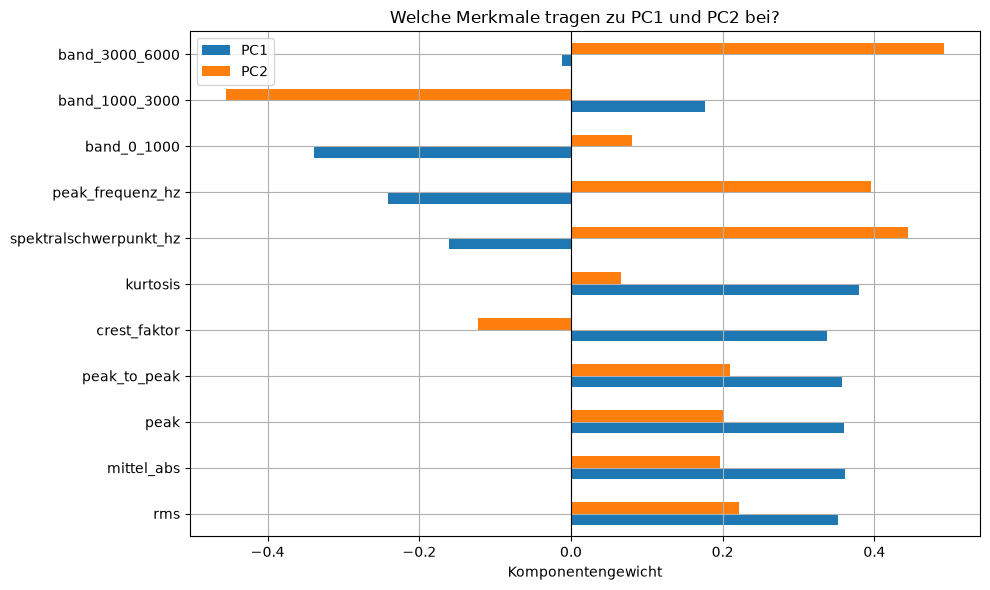

In [8]:
gewichte = pd.DataFrame(pca.components_.T, index=pca_spalten, columns=namen)
display(gewichte[["PC1", "PC2"]].round(3))
gewichte[["PC1", "PC2"]].plot.barh(figsize=(10, 6))
plt.xlabel("Komponentengewicht"); plt.axvline(0, color="black", linewidth=0.8)
plt.title("Welche Merkmale tragen zu PC1 und PC2 bei?")
plt.tight_layout(); plt.show()

Wir rechnen PC1 für ein Messfenster selbst aus:

`PC1 = Gewicht₁ × z₁ + Gewicht₂ × z₂ + ...`

Dabei wird zusätzlich der beim PCA-Fit gelernte Mittelpunkt abgezogen. Nach Standardisierung ist er hier numerisch fast null. Die Summe der einzelnen Beiträge ist der neue Merkmalswert.

In [9]:
zeile = 0
beitraege = pd.DataFrame({
    "z_Wert": Z[zeile] - pca.mean_,
    "PC1_Gewicht": pca.components_[0],
}, index=pca_spalten)
beitraege["Beitrag"] = beitraege.z_Wert * beitraege.PC1_Gewicht
display(beitraege.round(4))
pc1_selbst = beitraege.Beitrag.sum()
print(f"Selbst berechnet: {pc1_selbst:.6f}; sklearn: {scores[zeile, 0]:.6f}")
assert np.isclose(pc1_selbst, scores[zeile, 0])
neue_features = features[["aufnahme", "zustand", "fenster"]].copy()
neue_features["PC1"] = scores[:, 0]
neue_features["PC2"] = scores[:, 1]
display(neue_features.head().round(3))

,z_Wert,PC1_Gewicht,Beitrag
rms,-0.9360,0.3527,-0.3301
mittel_abs,-0.9836,0.3611,-0.3552
peak,-0.9460,0.3604,-0.3410
peak_to_peak,-0.9403,0.3576,-0.3363
crest_faktor,-0.6920,0.3370,-0.2332
kurtosis,-1.0196,0.3793,-0.3867
spektralschwerpunkt_hz,0.9624,-0.1613,-0.1552
peak_frequenz_hz,1.4024,-0.2410,-0.3380
band_0_1000,2.0590,-0.3385,-0.6971
band_1000_3000,-1.3346,0.1765,-0.2355


Selbst berechnet: -3.413237; sklearn: -3.413237


,aufnahme,zustand,fenster,PC1,PC2
0,97,gesund,0,-3.413,1.199
1,97,gesund,1,-3.429,1.645
2,97,gesund,2,-3.580,1.456
3,97,gesund,3,-3.279,1.349
4,97,gesund,4,-3.556,1.466


## 6. Die neuen Merkmale anschauen
Wir verwenden die bekannten Zustände nur zum Einfärben. Der Abstand im Diagramm beschreibt Unterschiede in den ersten beiden Komponenten. Alles außerhalb dieser Projektion ist unsichtbar. Jeder Zustand stammt hier aus nur einer Aufnahme: Auch getrennte Punktwolken beweisen keine Generalisierung auf neue Lager.

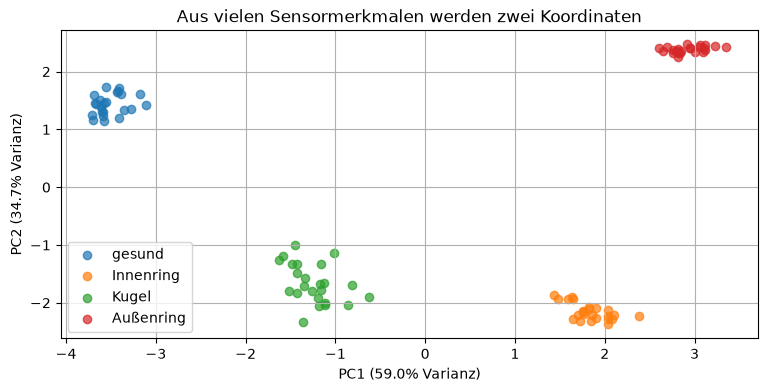

In [10]:
for zustand, gruppe in neue_features.groupby("zustand", sort=False):
    plt.scatter(gruppe.PC1, gruppe.PC2, label=zustand, alpha=0.7)
plt.xlabel(f"PC1 ({varianz[0]:.1%} Varianz)")
plt.ylabel(f"PC2 ({varianz[1]:.1%} Varianz)")
plt.title("Aus vielen Sensormerkmalen werden zwei Koordinaten")
plt.legend(); plt.show()

## 7. Wie viel Information verlieren wir?
Wir rekonstruieren die standardisierten Merkmale aus den ersten zwei Komponenten. Der mittlere quadratische Rekonstruktionsfehler zeigt pro Merkmal, was die Projektion schlecht bewahrt. Das ist ein Informationsverlust in dieser Datentabelle, keine Vorhersagefehlerrate.

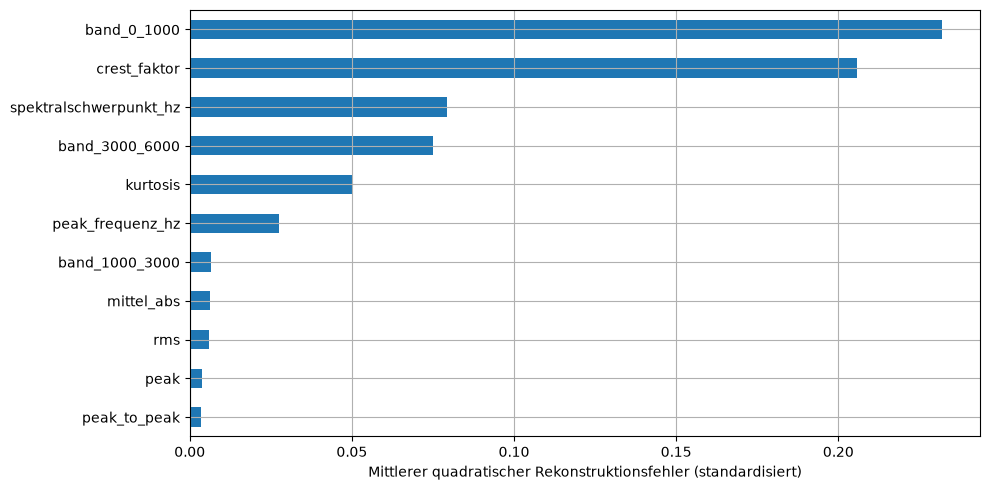

In [11]:
Z_rekonstruiert = scores[:, :2] @ pca.components_[:2] + pca.mean_
fehler = pd.Series(np.mean((Z - Z_rekonstruiert) ** 2, axis=0), index=pca_spalten)
fehler.sort_values().plot.barh(figsize=(10, 5))
plt.xlabel("Mittlerer quadratischer Rekonstruktionsfehler (standardisiert)")
plt.tight_layout(); plt.show()

## Zum Ausprobieren
1. Nenne zwei stark zusammenhängende Merkmale. Prüfe den Zusammenhang im Scatterplot und getrennt je Zustand.
2. Welche drei Merkmale haben die größten absoluten PC1-Gewichte? Welche vorsichtige Interpretation passt dazu?
3. Berechne PC2 für Zeile 5 selbst und vergleiche mit `scores[5, 1]`.
4. Rekonstruiere mit einer, zwei und mit `k90` Komponenten. Wie verändert sich der Fehler?
5. Entferne `mittel_abs`, passe Skalierung/PCA neu an und vergleiche die Varianzanteile.

**Für spätere ML-Pipelines:** Skalierung und PCA ausschließlich auf Trainingsaufnahmen fitten und Testdaten nur transformieren. Hier fitten wir die gesamte kleine Tabelle für EDA. Zusätzliche unabhängige Aufnahmen sind für eine belastbare Evaluation nötig.